Soumya Dixit 23070521151

  Ticker        Date  Open  High   Low  Close  Adj Close     Volume
0   AAPL  2000-01-03  0.94  1.00  0.91   1.00       0.84  535796800
1   AAPL  2000-01-04  0.97  0.99  0.90   0.92       0.77  512377600
2   AAPL  2000-01-05  0.93  0.99  0.92   0.93       0.78  778321600
3   AAPL  2000-01-06  0.95  0.96  0.85   0.85       0.71  767972800
4   AAPL  2000-01-07  0.86  0.90  0.85   0.89       0.75  460734400
Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')
Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - loss: 1.6058e-04 - val_loss: 1.8310e-04
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 5.8161e-06 - val_loss: 1.7635e-04
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 5.8251e-06 - val_loss: 2.4735e-04
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 6.7961e-06 - val_loss: 1.9321e-04
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 5.9942e-06 - val_loss: 1.6999e-04
Epoc

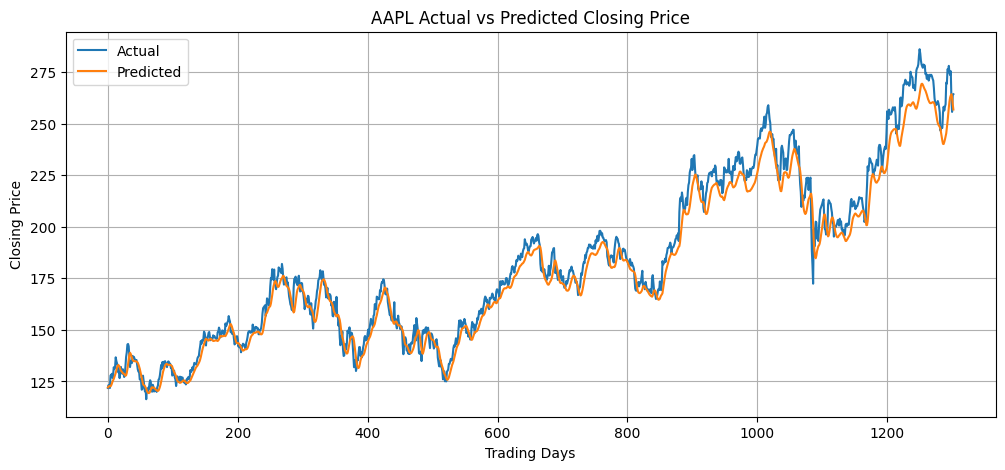

In [ ]:
#riya_varma_23070521118
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam


# 1. Load Kaggle Dataset
data = pd.read_csv("NASDAQ100_Historical_Data.csv")
print(data.head())
print(data.columns)
# 2. Select One Stock
# Change AAPL to any ticker available in your dataset
data = data[data["Ticker"] == "AAPL"].copy()
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
# 3. Select Closing Price
prices = data[["Close"]].values

# 4. Normalize Data
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)
# 5. Create 60-Day Sequences
X, y = [], []
days = 60

for i in range(days, len(prices)):
    X.append(prices[i-days:i])
    y.append(prices[i])

X = np.array(X)
y = np.array(y)


# 6. Train-Test Split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]
# 7. Build LSTM Model
model = Sequential([
    Input(shape=(60, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(1)
])
# 8. Compile
model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)
# 9. Train
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
# 10. Predict
pred = model.predict(X_test, verbose=0)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test)
# 11. Evaluate
mae = mean_absolute_error(actual, pred)
mse = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)

print("\nMAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
# 12. Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("AAPL Actual vs Predicted Closing Price")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()